## Data Preprocessing Part

In [6]:
import pandas as pd

In [7]:
data = pd.read_csv('/home/davidsalome/workspace/Machine-Learning-Portfolio/1_Supervised_Learning/linearRegression/housing.csv')

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
data = data.dropna()

In [9]:
data["ocean_proximity"].value_counts()
# As we can see that the ocean proximity column is a categorical variable, we will need to convert it into numerical values using one-hot encoding.
# I guess the value count of island is very low, so we can drop that column as it will not have much impact on the model.

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [10]:
# Lets change the ocean proximity column into numerical values using one-hot encoding.
categorical_columns = ['ocean_proximity']
data = pd.get_dummies(data, columns=categorical_columns, dtype=int)

In [11]:
data.head()
data = data.drop('ocean_proximity_ISLAND', axis=1) # Dropping the island column as it has very low value counts and will not have much impact on the model.

## Define Target and Features

In [12]:
y = data['median_house_value'] # This is our target variable that we need to predict.
features = data.drop('median_house_value', axis=1) # These are the features that we will use to predict the target variable.
features.columns = (
    features.columns.str.replace('[', '', regex=False).str.replace(']','',regex=False).str.replace('<', '',regex=False)
)

## Model

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

In [14]:
# Make instance of the model
import xgboost as xgb
clf = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=5, # Maximum depth of each tree
    learning_rate=0.1,
    n_estimators=100, # No of trees
    subsample=0.5, # Instead of giving the model the whole 70000 dataset to learn it gives a sample of data for training
    colsample_bytree=0.8, # Feature sampling rate    
)

# Train the model
clf.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
# We can now use the trained model to make predictions on the test set and evaluate its performance. Let's do that next.
y_pred = clf.predict(X_test)
# print("Predictions: ", y_pred[:5])  # Print first 5 predictions
comparison = pd.DataFrame(
    {"Actual": y_test.values[:5], "Predicted": y_pred[:5]}
)
print(comparison)

     Actual      Predicted
0  245800.0  221595.890625
1  137900.0  140406.203125
2  218200.0  202369.875000
3  220800.0  133575.343750
4  170500.0  184410.843750


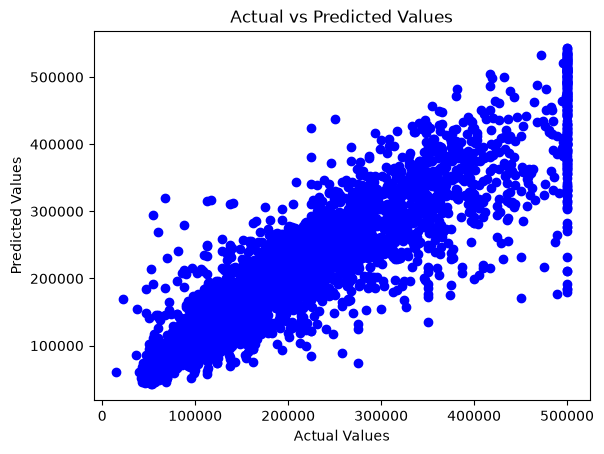

In [16]:
# Visualize the predictions against the actual values
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [17]:
# Print the mean squared error and R-squared value to evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error: ", mse)
print("R-squared: ", r2)

Mean Squared Error:  2530791086.27674
R-squared:  0.8149354567320505


## XGBoost on house price detection and model comparision Linear Regression VS XGBoost
- In this house price prediction task, I compared a Gradient Boosting model (XGBoost) against a baseline Linear Regression model. Interestingly, Linear Regression achieved a slightly higher R-squared score of 0.848 (with an MSE of ~8.20) compared to XGBoost's R-squared of 0.815 and Mean Squared Error of 2,530,791,086. This suggests that the dataset contains strong linear relationships that a simple linear model captures efficiently, whereas the default tree ensemble may require further tuning.

- For the XGBoost model, we tuned key hyperparameters: max_depth=5 to restrict tree growth and prevent overfitting, learning_rate=0.1 to ensure stable gradient descent updates, and n_estimators=100 to provide adequate boosting rounds. The actual-versus-predicted scatter plot confirms that both models successfully track general housing price trends, clustering closely along the ideal reference line across the test dataset.